In [19]:
from datetime import datetime
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import json

ROOT_PATH = "D:/AI_data_analysis/RMRB/"

In [17]:
def Json_Dict(Json_Path):
    """
    Json_Path: Path of a json file
    """
    with open(Json_Path, 'r', encoding='utf-8') as file:
        data_dict = json.load(file)  # Read and convert JSON to a dictionary
    return data_dict

def Dict_To_Json(Dict, Json_Path):
    """
    Dict: any dict format variable in python

    Json_Path: Path of a json file
    """
    with open(Json_Path, 'w', encoding='utf-8') as file:
        json.dump(Dict, file, ensure_ascii=False, indent=4)  # Write as formatted JSON

def Build_Text_DF(
        YEAR, Begin_date="0101", End_date="1231", 
        Model_Name="RMRB_model_2", Max_Len=1024,
        Text_Type: str="Pytesseract_Text", 
        Text_Language: list=["E_C", "C"]
    ):
    def TEXT_DF(Date_List, Ad_Name_List, 
                Model_List, Summarized_Text_List,
                Json_Link_List, Image_Link_list,
                Path_Bool: str=False):
        DF_Dict = {}
        DF_Dict["Date"] = Date_List
        DF_Dict["Ad_Name"] = Ad_Name_List
        DF_Dict["Model"] = Model_List
        DF_Dict["Summarized_Text"] = Summarized_Text_List
        if Path_Bool:
            DF_Dict["Json_Link"] = Json_Link_List
            DF_Dict["Image_Link"] = Image_Link_list
        DF = pd.DataFrame(DF_Dict)
        DF["Date"] = pd.to_datetime(DF["Date"])
        print("Text Dataframe built!")
        return DF

    FOLD_PATH = ROOT_PATH + f"{YEAR}_AD/"
    start_date = datetime(int(YEAR), int(Begin_date[:2]), int(Begin_date[2:]))
    end_date = datetime(int(YEAR), int(End_date[:2]), int(End_date[2:]))

    filtered_json_names = []
    for filename in os.listdir(FOLD_PATH):
        file_path = os.path.join(FOLD_PATH, filename)
        name = filename.split(".")[0]
        suffix = filename.split(".")[1]
        # Check if it is a file (not a directory)
        if os.path.isfile(file_path):  # Ensure it is a file
            if suffix == "json": # Ensure it is json file
                date_str = name.split("_")[0]  # Get the date part
                file_date = datetime.strptime(
                    date_str, "%Y%m%d")  # Convert to datetime object
                # Check if the file date is within the specified range
                if start_date <= file_date <= end_date:
                    filtered_json_names.append(filename)
    Date_List = []
    Ad_Name_List = []
    Model_List = []
    Summarized_Text_List = []
    Json_Link_List = []
    Image_Link_list = []
    # For example: DF_Dict = {"Date": [1], "Ad_Name": [4], "Model": [1], "Summarized_Text": [1]}
    # pd.DataFrame(DF_Dict)
    print("*" * 60)
    print(f"{Text_Type}_{Text_Language} summarized by {Model_Name}_m{Max_Len}")
    DATE_i= filtered_json_names[0].split("_")[0]
    print("*" * 60)
    print(DATE_i)
    for json_name in filtered_json_names:
        NAME = json_name.split(".")[0]
        json_path = os.path.join(FOLD_PATH, json_name)
        image_path = json_path.split(".")[0] + ".png"
        # Create a clickable link
        # image_link = f'<a href="file:///{image_path}" target="_blank">Image_Link</a>'
        # json_link = f'<a href="file:///{json_path}" target="_blank">Json_Link</a>'
        DATE = json_name.split("_")[0]
        if DATE != DATE_i:  # This is used for date print
            print("*" * 60)
            print(DATE)
            DATE_i = DATE
        # Checking if the JSON file exists
        if os.path.exists(json_path):
            # Load the existing data from the JSON file
            print(f"{NAME}")
            print(f"{image_path}")
            print(f"{json_path}")
            Json_Data_Dict = Json_Dict(json_path)
            for Lan in Text_Language:
                Summary_Text_Name = f"{Text_Type}_{Lan}_{Model_Name}_m{Max_Len}"
                if Summary_Text_Name in Json_Data_Dict: # If the text has been summarized, pass it
                    summarized_text = Json_Data_Dict[Summary_Text_Name]
                    Date_List.append(DATE)
                    Ad_Name_List.append(NAME)
                    Model_List.append(Summary_Text_Name)
                    Summarized_Text_List.append(summarized_text)
                    Json_Link_List.append(json_path)
                    Image_Link_list.append(image_path)
                    print(f"{Lan}: {summarized_text}")
            print()
        else:
            print(f"{json_path} does not exist!")
    print("*" * 60)
    return TEXT_DF(Date_List, Ad_Name_List, 
                   Model_List, Summarized_Text_List,
                   Json_Link_List, Image_Link_list)
RMRB_DF = Build_Text_DF("2022")
# 1h

************************************************************
Pytesseract_Text_['E_C', 'C'] summarized by RMRB_model_2_m1024
************************************************************
20220101
20220101_8_FAD
D:/AI_data_analysis/RMRB/2022_AD/20220101_8_FAD.png
D:/AI_data_analysis/RMRB/2022_AD/20220101_8_FAD.json
E_C: 【今日头条】2016年10月19日
C: 【今日头条】扎真情贴近海外读者权威实力源自人民真诚服务

************************************************************
20220102
20220102_7_FAD
D:/AI_data_analysis/RMRB/2022_AD/20220102_7_FAD.png
D:/AI_data_analysis/RMRB/2022_AD/20220102_7_FAD.json
E_C: 陕西西凤酒股份有限公
C: 陕西西凤酒股份有限公

20220102_8_FAD
D:/AI_data_analysis/RMRB/2022_AD/20220102_8_FAD.png
D:/AI_data_analysis/RMRB/2022_AD/20220102_8_FAD.json
E_C: 贵州春茶贵如金
C: 2022年1月2日星期日贵州

************************************************************
20220104
20220104_13_HAD_Block_2
D:/AI_data_analysis/RMRB/2022_AD/20220104_13_HAD_Block_2.png
D:/AI_data_analysis/RMRB/2022_AD/20220104_13_HAD_Block_2.json
E_C: 【中冀扶贫】“中冀扶贫基金会. 冰雪大篷车”开启冰雪运动之旅
C: 中冀

In [18]:
RMRB_DF

,Date,Ad_Name,Model,Summarized_Text
0,2022-01-01,20220101_8_FAD,Pytesseract_Text_E_C_RMRB_model_2_m1024,【今日头条】2016年10月19日
1,2022-01-01,20220101_8_FAD,Pytesseract_Text_C_RMRB_model_2_m1024,【今日头条】扎真情贴近海外读者权威实力源自人民真诚服务
2,2022-01-02,20220102_7_FAD,Pytesseract_Text_E_C_RMRB_model_2_m1024,陕西西凤酒股份有限公
3,2022-01-02,20220102_7_FAD,Pytesseract_Text_C_RMRB_model_2_m1024,陕西西凤酒股份有限公
4,2022-01-02,20220102_8_FAD,Pytesseract_Text_E_C_RMRB_model_2_m1024,贵州春茶贵如金
...,...,...,...,...
2073,2022-12-30,20221230_16_FAD,Pytesseract_Text_C_RMRB_model_2_m1024,【旅游资讯】河北旅投集团：银河冰雪管理平
2074,2022-12-30,20221230_20_FAD,Pytesseract_Text_E_C_RMRB_model_2_m1024,【图说】金霞银光：打造现代养殖产业链链主
2075,2022-12-30,20221230_20_FAD,Pytesseract_Text_C_RMRB_model_2_m1024,【财经早餐】2016年10月12日星期五
2076,2022-12-30,20221230_8_FAD,Pytesseract_Text_E_C_RMRB_model_2_m1024,欧拉操作系统产业哲会召开


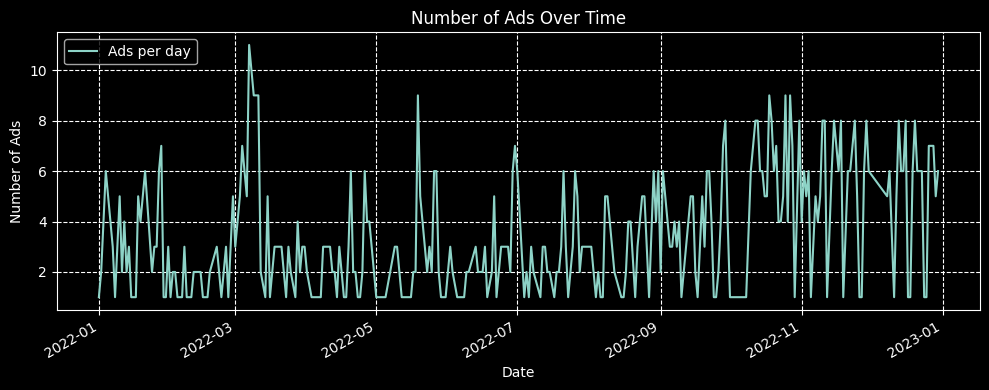

In [48]:
def AD_Num_Analysis(RMRB_DF):
    Model_Len = len(RMRB_DF["Model"].unique())
    RMRM_Len_DF = RMRB_DF.groupby("Date")["Ad_Name"].count() / Model_Len

    # Create a figure and axis  
    plt.figure(figsize=(10, 4))  
    
    # Plot the data  
    RMRM_Len_DF.plot(linestyle='-')  

    # Add titles and labels  
    plt.title('Number of Ads Over Time')  
    plt.xlabel('Date')  
    plt.ylabel('Number of Ads')  

    # Optional: Add a grid  
    plt.grid(True, linestyle='--')

    # Format the x-axis for better date readability  
    # plt.gcf().autofmt_xdate()  # Auto formats the x-axis to fit dates  

    # Add a legend if necessary  
    plt.legend(['Ads per day'], loc='upper left')  

    # Show the plot  
    plt.tight_layout()  # Adjusts the plot to ensure everything fits without overlap
    plt.show()  
AD_Num_Analysis(RMRB_DF)